<a href="https://colab.research.google.com/github/matheusbuttow/LLMs-com-bancos-de-dados-vetoriais/blob/main/canny_edge_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

(<Axes: title={'center': 'Tons de Cinza'}>,
 Text(0.5, 1.0, 'Tons de Cinza'))

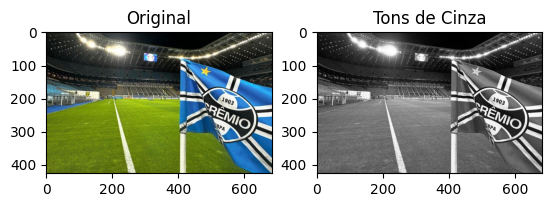

In [14]:
img = cv.imread('/content/PE4SMFIDDVFD7CHXZWBQ5UIVQY.jpg', cv.IMREAD_COLOR)
assert img is not None, "file could not be read, check with os.path.exists()"

#convertendo de BGR para RGB para compatibilizar com o matplotlib
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.subplot(121),plt.imshow(img),plt.title('Original')


#RGB para grayscale
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
plt.subplot(122),plt.imshow(img_gray, cmap = 'gray'),plt.title('Tons de Cinza')

(<Axes: title={'center': 'Suavizada (Sigma=2)'}>,
 Text(0.5, 1.0, 'Suavizada (Sigma=2)'),
 ([], []),
 ([], []))

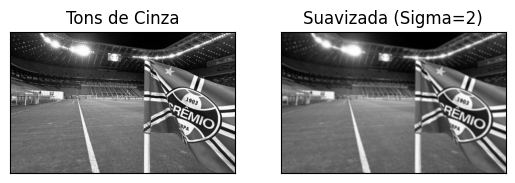

In [15]:
#Step 1 - Gaussian filtering - https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
plt.subplot(121),plt.imshow(img_gray, cmap = 'gray'),plt.title('Tons de Cinza'),plt.xticks([]), plt.yticks([])
img_blur = cv.GaussianBlur(img_gray, (5,5), 2)
plt.subplot(122),plt.imshow(img_blur, cmap = 'gray'),plt.title('Suavizada (Sigma=2)'),plt.xticks([]), plt.yticks([])

(Text(0.5, 1.0, 'Sobel Gradient y'), ([], []), ([], []))

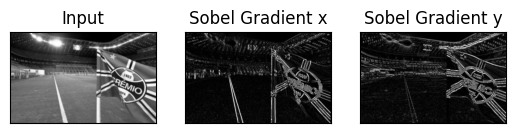

In [16]:
# Step 2 - Apply a basic gradient estimator (e.g.: Sobel or Prewitt)
#https://docs.opencv.org/3.4/d5/d0f/tutorial_py_gradients.html
#https://docs.opencv.org/3.4/d2/d2c/tutorial_sobel_derivatives.html

#prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
#prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
#grad_x = cv.filter2D(img,-1,prewitt_x)
#grad_y = cv.filter2D(img,-1,prewitt_y)


# Output dtype = cv.CV_64F
grad_x = cv.Sobel(img_blur,cv.CV_64F,1,0,ksize=3)
grad_y = cv.Sobel(img_blur,cv.CV_64F,0,1,ksize=3)

# Then take its absolute and convert to cv.CV_8U to show as an grayscale image
abs_grad_x = np.absolute(grad_x)
grad_x_8u = np.uint8(abs_grad_x)
abs_grad_y = np.absolute(grad_y)
grad_y_8u = np.uint8(abs_grad_y)

plt.subplot(1,3,1),plt.imshow(img_blur,cmap = 'gray')
plt.title('Input'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(grad_x_8u,cmap = 'gray')
plt.title('Sobel Gradient x'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(grad_y_8u,cmap = 'gray')
plt.title('Sobel Gradient y'), plt.xticks([]), plt.yticks([])

(<Axes: title={'center': 'Direção (rad)'}>,
 Text(0.5, 1.0, 'Direção (rad)'),
 ([], []),
 ([], []))

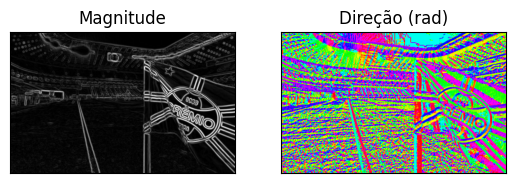

In [18]:
# Step 2.1 - Magnitude and Direction
# Step 2.1 - Magnitude and Direction

# Magnitude do gradiente: sqrt(Gx^2 + Gy^2)
magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Direção do gradiente em radianos: atan2(Gy, Gx)
direction = np.arctan2(grad_y, grad_x)

# Normalizando a magnitude para visualização (0-255)
magnitude_norm = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.subplot(121), plt.imshow(magnitude_norm, cmap='gray'), plt.title('Magnitude'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(direction, cmap='hsv'), plt.title('Direção (rad)'), plt.xticks([]), plt.yticks([])

(<Axes: title={'center': 'Apos NMS'}>,
 Text(0.5, 1.0, 'Apos NMS'),
 ([], []),
 ([], []))

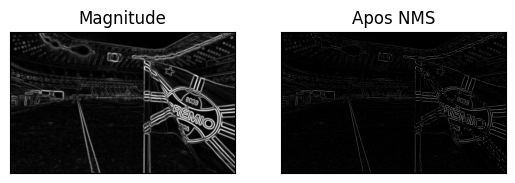

In [20]:
# Step 3 - Non-maxima suppression

def non_maxima_suppression(magnitude, direction):
    H, W = magnitude.shape
    nms = np.zeros((H, W), dtype=np.float64)

    angle = direction.copy()
    angle[angle < 0] += 180

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            a = angle[i, j]

            if (0 <= a < 22.5) or (157.5 <= a <= 180):
                neighbors = (magnitude[i, j-1], magnitude[i, j+1])
            elif 22.5 <= a < 67.5:
                neighbors = (magnitude[i-1, j+1], magnitude[i+1, j-1])
            elif 67.5 <= a < 112.5:
                neighbors = (magnitude[i-1, j], magnitude[i+1, j])
            else:
                neighbors = (magnitude[i-1, j-1], magnitude[i+1, j+1])

            if magnitude[i, j] >= neighbors[0] and magnitude[i, j] >= neighbors[1]:
                nms[i, j] = magnitude[i, j]

    return nms

img_nms = non_maxima_suppression(magnitude, direction)

plt.subplot(121), plt.imshow(magnitude, cmap='gray'), plt.title('Magnitude'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_nms, cmap='gray'), plt.title('Apos NMS'), plt.xticks([]), plt.yticks([])

(<Axes: title={'center': 'Bordas finais (Canny manual)'}>,
 Text(0.5, 1.0, 'Bordas finais (Canny manual)'),
 ([], []),
 ([], []))

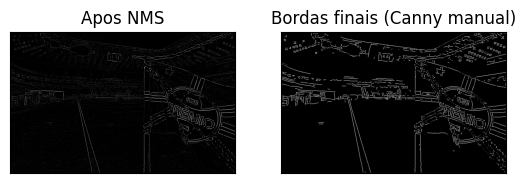

In [22]:
# Step 4 - Edge following

def edge_following(img_nms, low_threshold, high_threshold):
    H, W = img_nms.shape
    result = np.zeros((H, W), dtype=np.uint8)

    strong = img_nms >= high_threshold
    weak = (img_nms >= low_threshold) & (img_nms < high_threshold)

    result[strong] = 255

    visited = strong.copy()
    stack = list(zip(*np.where(strong)))

    while stack:
        y, x = stack.pop()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                ny, nx = y + dy, x + dx
                if 0 <= ny < H and 0 <= nx < W and not visited[ny, nx] and weak[ny, nx]:
                    visited[ny, nx] = True
                    result[ny, nx] = 255
                    stack.append((ny, nx))

    return result

low_threshold = 40
high_threshold = 100
img_edges = edge_following(img_nms, low_threshold, high_threshold)

plt.subplot(121), plt.imshow(img_nms, cmap='gray'), plt.title('Apos NMS'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_edges, cmap='gray'), plt.title('Bordas finais (Canny manual)'), plt.xticks([]), plt.yticks([])